In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\coffee_shop.csv",encoding='UTF-8')

In [ ]:
df['revenue'] = df['unit_price'] * df['transaction_qty']
df['datetime'] = pd.to_datetime(df['transaction_date']+' '+df['transaction_time'],format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df['week'] = df['datetime'].dt.weekday
df['month'] = df['datetime'].dt.to_period('M')
#
# df['week_day'] = df['datetime'].dt.weekday
# holydays = df[df['week_day']>=5]
# workdays = df[df['week_day']<5]
#
is_weekend = (df['datetime'].dt.weekday >= 5)
holydays = df[is_weekend]
workdays = df[~is_weekend]

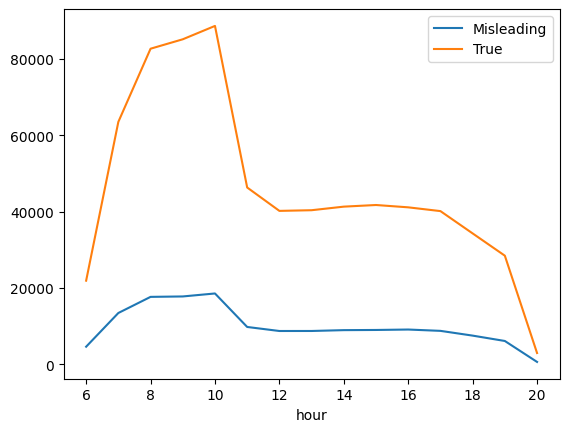

In [5]:
#hourly sales trend
mis_data = df.groupby('hour')['revenue'].sum()#wrong
data = df.groupby('hour')['transaction_id'].nunique()
data.plot(kind='line',label='Misleading')
mis_data.plot(label='True')
plt.legend()

<Axes: xlabel='transaction_date'>

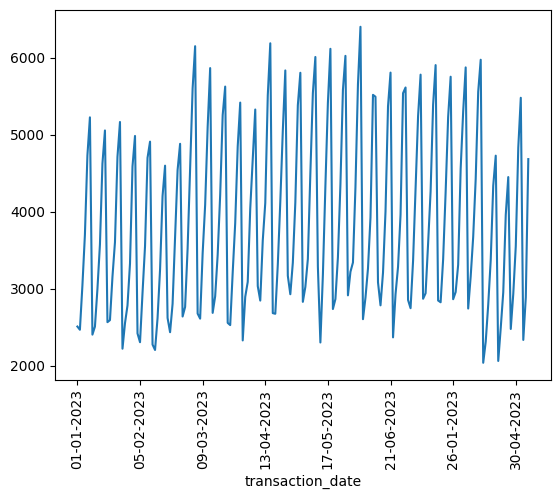

In [6]:
#daily revenue trend
data = df.groupby('transaction_date')['revenue'].sum()
data.plot(rot=90)

,total_revenues,total_orders,avg_order_value
store_location,,,
Hell's Kitchen,236511.17,50735,4.661696
Astoria,232243.91,50599,4.589891
Lower Manhattan,230057.25,47782,4.814726


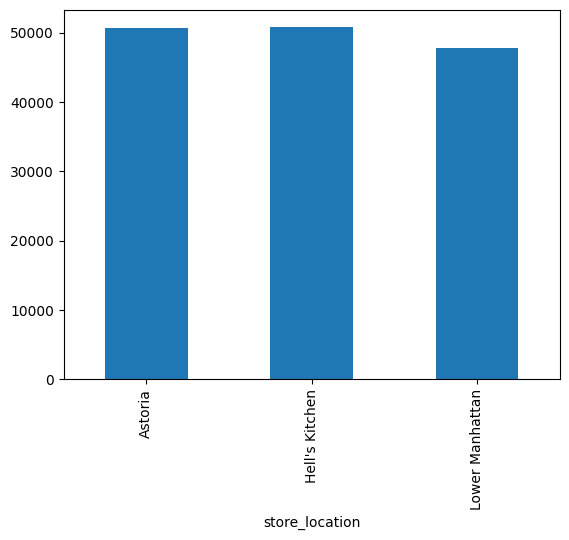

In [9]:

#store perforance comparison
data = df.groupby('store_location')['transaction_id'].nunique()
data.plot(kind='bar')
#improvement
store_perf = df.groupby('store_location').agg(
    total_revenues=('revenue','sum'),
    total_orders=('transaction_id','nunique')
)
store_perf['avg_order_value'] = store_perf['total_revenues']/store_perf['total_orders']
store_perf.sort_values(by='total_revenues',ascending=False)


<Axes: >

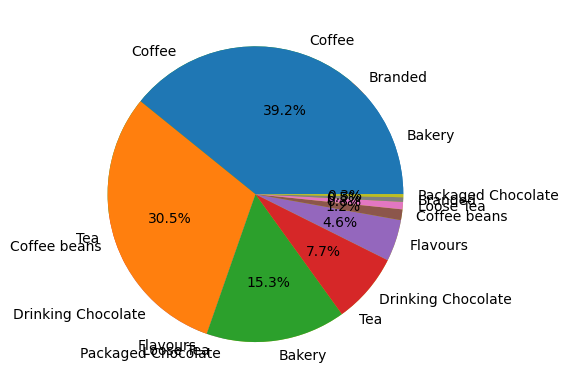

In [8]:
df.groupby('product_category')['revenue'].sum().plot(kind='pie')
#improvement
df['product_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')

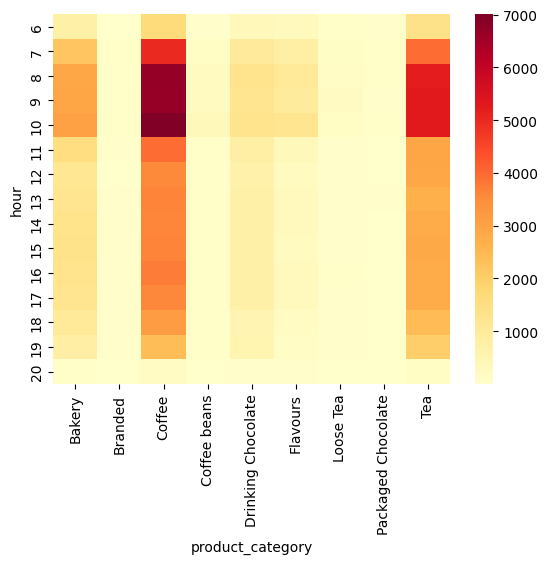

In [ ]:
#df.groupby('product_type')['transaction_qty'].sum().head(10).plot(kind='bar')
g = df.groupby('hour')['product_category'].value_counts().unstack(fill_value=0)
import seaborn as sns
sns.heatmap(g,
            cmap='YlOrRd')
pvt_table = df.pivot_table(index='hour',values=['product_category'],
                           aggfunc='value_counts')

C:\Users\user\AppData\Local\Temp\ipykernel_11972\2742203617.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour


<Axes: xlabel='hour', ylabel='date'>

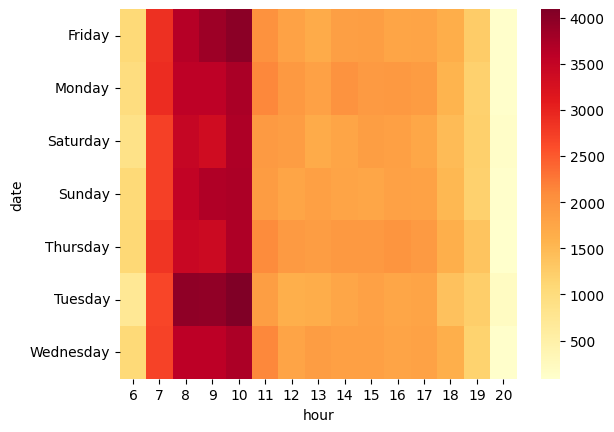

In [10]:
import seaborn as sns

df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
df['date'] = df['datetime'].dt.day_name()

pivot = df.pivot_table(index='date',
                       columns='hour',
                       values='transaction_qty',
                       aggfunc='sum')

sns.heatmap(pivot, cmap='YlOrRd')

In [11]:
#1 hour-wise number of transactions using a line chart
gb = df.groupby(['hour'])['transaction_id'].nunique()
pt = df.pivot_table(index='hour',values=['transaction_id'],
               aggfunc='nunique')
# gb.plot(kind='line')
# pt.plot(kind='line')

In [12]:
#2 daily total revenue trend over time using a line plot
df['day_wise'] = df['datetime'].dt.date
df['day_wise'] = df['datetime'].dt.to_period("D")#true daily trend
gb = df.groupby('day_wise')['revenue'].sum()
pt = df.pivot_table(index='day_wise',values='revenue',aggfunc='sum')
#pt.plot()

In [13]:
#3 total revenue across store location
pt = df.pivot_table(index='store_location',values='revenue',aggfunc='sum')#columns='hour'
#pt.plot(kind='bar')

#improvement
pt = df.pivot_table(index='store_location', values='revenue', aggfunc='sum').reset_index()

#pt.plot(kind='bar', x='store_location', y='revenue', 
        # title='Total Revenue by Store Location',
        # xlabel='Location',
        # ylabel='Revenue',
        # legend=False,
        # rot=45)  # rotate x labels if location names are long

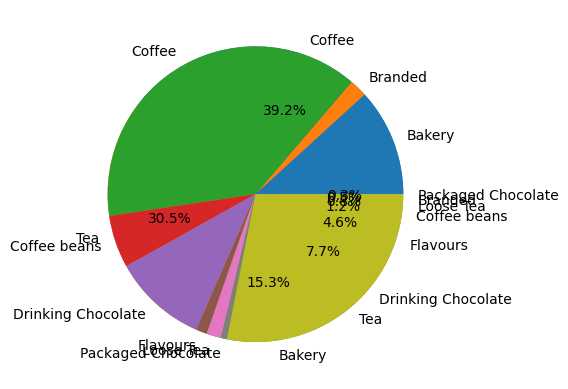

In [14]:
#4 distribution of product categories using pie chart
customer_preference = df['product_category'].value_counts().plot(kind='pie',autopct = '%1.1f%%')
revenue_analysis = df.groupby('product_category')['revenue'].sum().plot(kind='pie')


In [15]:
#5 top 10 best selling product types

gb = df.groupby('product_category')['revenue'].sum()
pt = df.pivot_table(index='product_category',values='revenue',aggfunc='sum')
#pt.reset_index().sort_values('revenue',ascending=False).head(10).plot(x='product_category',y='revenue',kind='bar')


In [16]:
#6 heatmap of weekday and transactions by hour
pt = df.pivot_table(index=df['datetime'].dt.day_name(),columns='hour',values='transaction_id',
                    aggfunc='nunique')

#sns.heatmap(pt,cmap='YlOrRd')
#improvement
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pt = df.pivot_table(index=df['datetime'].dt.day_name(),
                    columns='hour',
                    values='transaction_id',
                    aggfunc='nunique')
pt = pt.reindex(day_order)
##
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pt = df.pivot_table(index=df['datetime'].dt.day_name(),
                    columns='hour',
                    values='transaction_id',
                    aggfunc='nunique').reindex(day_order)

#sns.heatmap(pt,cmap='YlOrRd',annot=True,fmt='g',linewidths=0.5)    # grid lines between cells


In [17]:
#8 average unit price per product category using a bar chart.
#df.groupby('product_category')['unit_price'].mean().plot(kind='bar',x='unit_price',y='product_category')


In [18]:
#10 monthly trend of revenue
#df.groupby('month')['revenue'].sum().plot()

<Axes: >

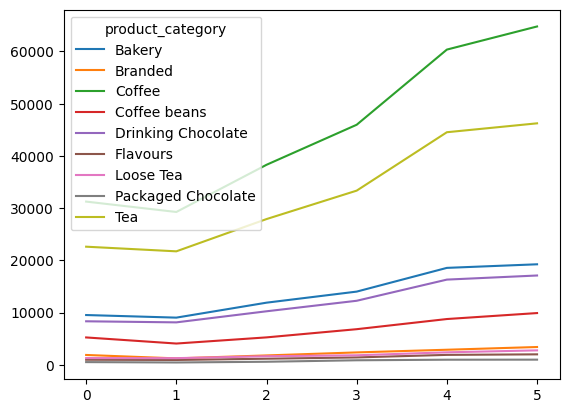

In [19]:
#11 coffe vs tea sale -> line graph
pt = df.pivot_table(index='month',columns='product_category',values='revenue',aggfunc='sum')
pt = pt.reset_index()
pt
pt.plot(kind='line')

<Axes: xlabel='month'>

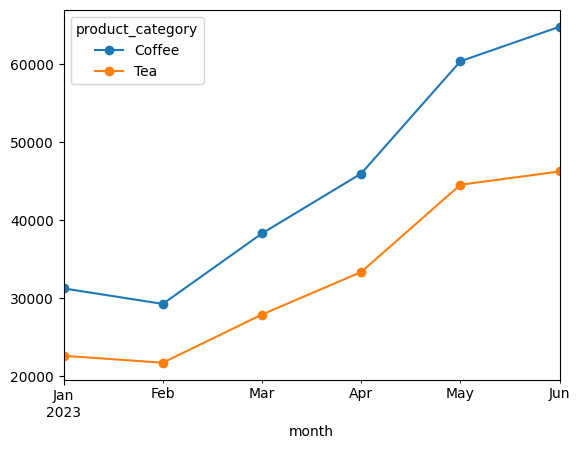

In [20]:
pt = df[df['product_category'].isin(['Coffee','Tea'])]\
     .pivot_table(index='month',
                  columns='product_category',
                  values='revenue',
                  aggfunc='sum')

pt.plot(kind='line', marker='o')

In [25]:
#12 transaction quantity distribution using histogram.
#df['transaction_qty'].value_counts().plot(kind='bar')

(array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(1, 0, 'Bakery'),
  Text(2, 0, 'Branded'),
  Text(3, 0, 'Coffee'),
  Text(4, 0, 'Coffee beans'),
  Text(5, 0, 'Drinking Chocolate'),
  Text(6, 0, 'Flavours'),
  Text(7, 0, 'Loose Tea'),
  Text(8, 0, 'Packaged Chocolate'),
  Text(9, 0, 'Tea')])

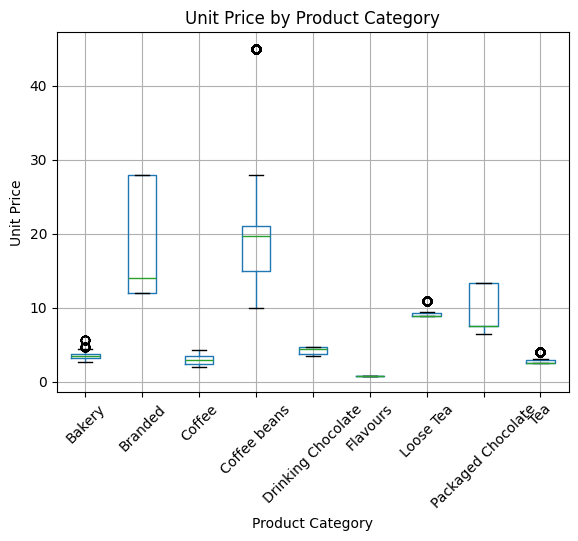

In [30]:
#13 boxplot of unit_price by product_category
df.boxplot(column='unit_price', by='product_category')
plt.title('Unit Price by Product Category')
plt.suptitle('')   # removes default pandas subtitle
plt.xlabel('Product Category')
plt.ylabel('Unit Price')
plt.xticks(rotation=45)

C:\Users\user\AppData\Local\Temp\ipykernel_11972\4007226287.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='product_category', y='unit_price',


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Coffee'),
  Text(1, 0, 'Tea'),
  Text(2, 0, 'Drinking Chocolate'),
  Text(3, 0, 'Bakery'),
  Text(4, 0, 'Flavours'),
  Text(5, 0, 'Loose Tea'),
  Text(6, 0, 'Coffee beans'),
  Text(7, 0, 'Packaged Chocolate'),
  Text(8, 0, 'Branded')])

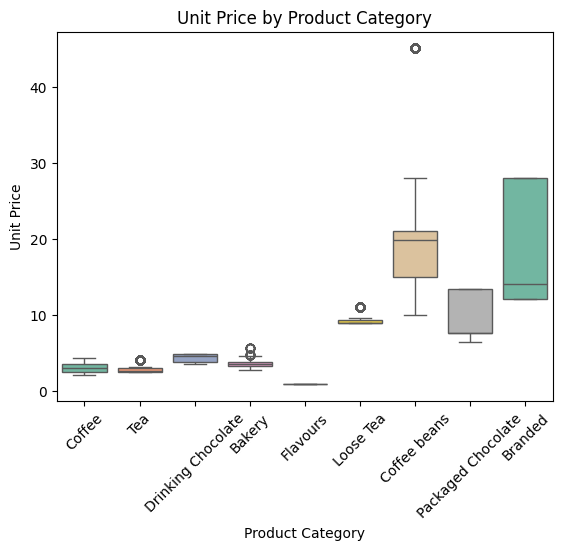

In [33]:
sns.boxplot(data=df, x='product_category', y='unit_price',
            palette='Set2')
plt.title('Unit Price by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Unit Price')
plt.xticks(rotation=45)

<Axes: xlabel='store_location'>

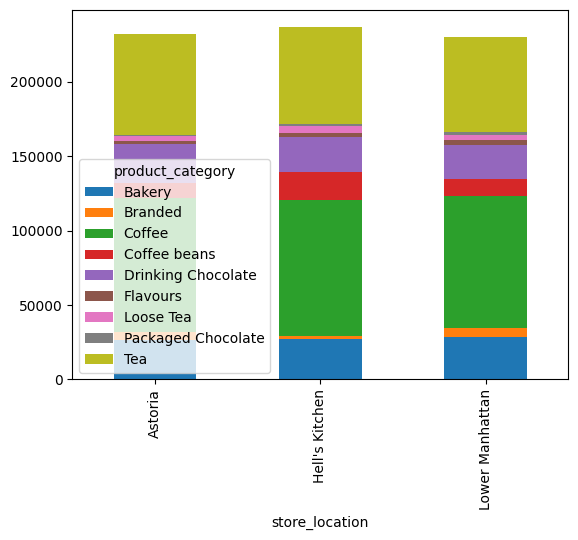

In [35]:
#14 store-wise product category sales comparison (stacked bar chart).
pt = df.pivot_table(index='store_location',
               columns='product_category',
               values='revenue',
               aggfunc='sum')
pt.plot(kind='bar',stacked=True)

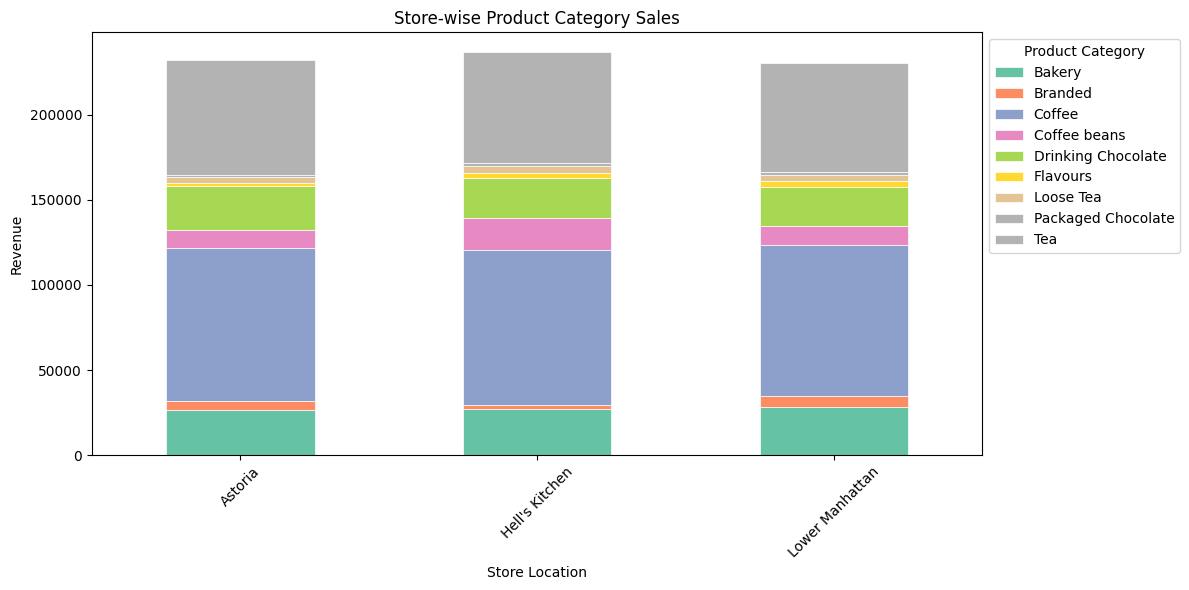

In [38]:
pt = df.pivot_table(index='store_location',
                    columns='product_category',
                    values='revenue',
                    aggfunc='sum')

pt.plot(kind='bar', 
        stacked=True,
        figsize=(12, 6),
        colormap='Set2',        # nicer colors
        edgecolor='white',      # separation between segments
        linewidth=0.5)

plt.title('Store-wise Product Category Sales')
plt.xlabel('Store Location')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product Category', 
           bbox_to_anchor=(1,1),   # legend outside plot ✅
           loc='upper left')
plt.tight_layout()

<Axes: xlabel='store_location'>

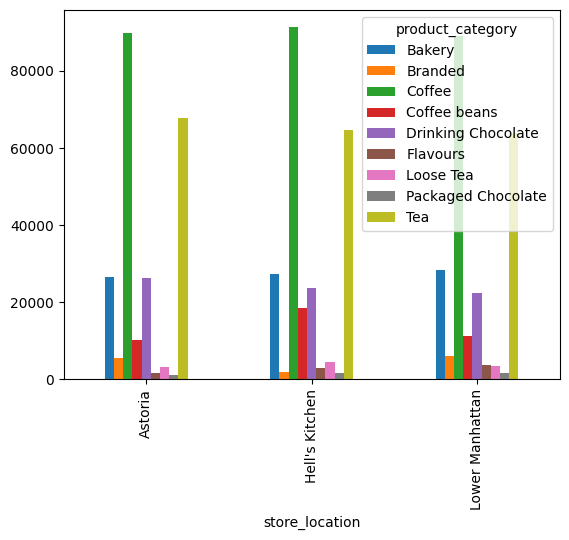

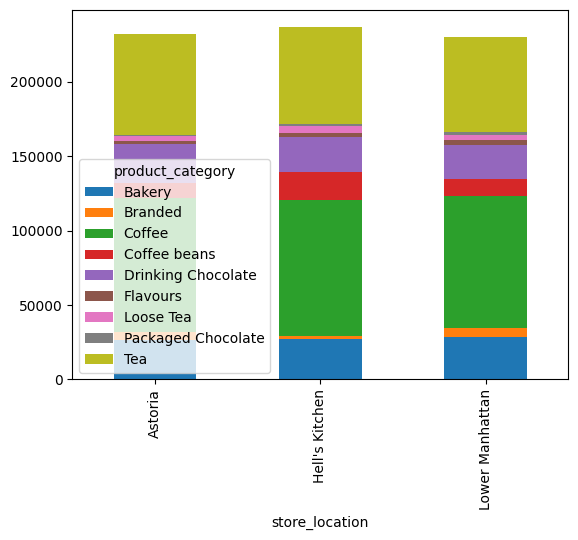

In [39]:
# grouped — easier to compare exact values per category
pt.plot(kind='bar', stacked=False)

# stacked — easier to compare total revenue per store
pt.plot(kind='bar', stacked=True)

<Axes: xlabel='hour'>

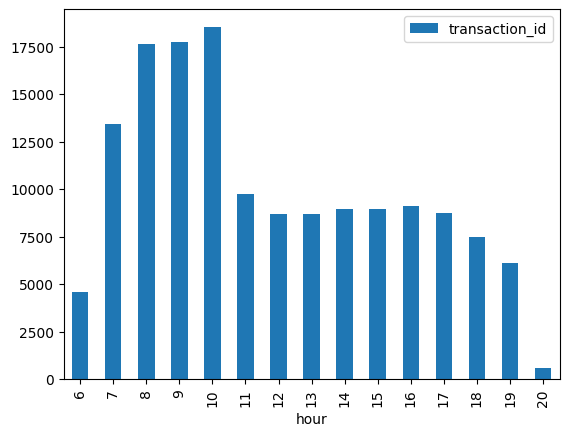

In [45]:
#15 peak business hours using visualization only.
g = df.pivot_table(index='hour',values='transaction_id',aggfunc='nunique')
g.plot(kind='bar')